In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        # print(os.path.join(dirname, filename))
        pass

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import pandas as pd

# Paste your copied file path between the quotation marks
df = pd.read_csv('/kaggle/input/datasets/devzohaib/eligibility-prediction-for-loan/Loan_Data.csv')

# View the first few rows of your data
df.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [4]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [5]:
df2 = df.drop(columns=['Loan_ID'])
df2.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [6]:
df2.duplicated().sum()

np.int64(0)

In [7]:
print(df2['Loan_Status'].value_counts())

Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [8]:
df2.isnull().sum()

Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
df2.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [10]:
cat_cols = ["Gender", "Married", "Dependents", "Self_Employed", "Credit_History"]

for col in cat_cols:
    df2[col] = df2[col].fillna(df2[col].mode()[0])

num_cols = ["LoanAmount", "Loan_Amount_Term"]

for col in num_cols:
    df2[col] = df2[col].fillna(df2[col].median())

In [11]:
df2.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [12]:
uniq_cols = ["Gender", "Married","Education", "Dependents", "Self_Employed","Property_Area"]

for col in uniq_cols:
    print(df2[col].unique().tolist())

['Male', 'Female']
['No', 'Yes']
['Graduate', 'Not Graduate']
['0', '1', '2', '3+']
['No', 'Yes']
['Urban', 'Rural', 'Semiurban']


In [13]:
df2['Gender']=df2['Gender'].map({"Male":1,"Female":0})
df2['Married']=df2['Married'].map({"Yes":1,"No":0})
df2['Education']=df2['Education'].map({"Graduate":1,"Not Graduate":0})
df2['Self_Employed']=df2['Self_Employed'].map({"Yes":1,"No":0})
df2['Dependents']=df2['Dependents'].map({"0":0,"1":1,"2":2,"3+":3})
df2.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Urban,Y
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,Rural,N
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Urban,Y
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Urban,Y


In [14]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    int64  
 1   Married            614 non-null    int64  
 2   Dependents         614 non-null    int64  
 3   Education          614 non-null    int64  
 4   Self_Employed      614 non-null    int64  
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         614 non-null    float64
 8   Loan_Amount_Term   614 non-null    float64
 9   Credit_History     614 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(6), object(2)
memory usage: 57.7+ KB


In [15]:
df2 = pd.get_dummies(df2, columns=['Property_Area'], dtype=int)
df2.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,1,0,5849,0.0,128.0,360.0,1.0,Y,0,0,1
1,1,1,1,1,0,4583,1508.0,128.0,360.0,1.0,N,1,0,0
2,1,1,0,1,1,3000,0.0,66.0,360.0,1.0,Y,0,0,1
3,1,1,0,0,0,2583,2358.0,120.0,360.0,1.0,Y,0,0,1
4,1,0,0,1,0,6000,0.0,141.0,360.0,1.0,Y,0,0,1


In [16]:
X = df2.drop(columns='Loan_Status')
y = df2['Loan_Status']
X.shape,y.shape


((614, 13), (614,))

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape,X_test.shape,y_train.shape,y_test.shape


((491, 13), (123, 13), (491,), (123,))

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report 

lr_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(random_state=42)
)

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
y_pred_lr

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y'], dtype=object)

In [19]:
from sklearn.pipeline import make_pipeline
from sklearn.naive_bayes import GaussianNB

gnb_pipeline = make_pipeline(
    GaussianNB()
)

gnb_pipeline.fit(X_train, y_train)

y_pred_gnb = gnb_pipeline.predict(X_test)
y_pred_gnb

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'Y', 'Y',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'N',
       'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y',
       'N', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N'], dtype='<U1')

In [20]:
 from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Logistic Regression
print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Gaussian Naive Bayes
print("\nGaussian Naive Bayes")
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test, y_pred_gnb))
print(classification_report(y_test, y_pred_gnb))

Logistic Regression
Accuracy: 0.7886178861788617
[[18 25]
 [ 1 79]]
              precision    recall  f1-score   support

           N       0.95      0.42      0.58        43
           Y       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123


Gaussian Naive Bayes
Accuracy: 0.7804878048780488
[[18 25]
 [ 2 78]]
              precision    recall  f1-score   support

           N       0.90      0.42      0.57        43
           Y       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



In [21]:
# check with cross validation
param_grid_lr = {
    "logisticregression__C": [0.01, 0.1, 1, 10, 100],
    "logisticregression__solver": ["liblinear", "lbfgs"],
    "logisticregression__penalty": ["l2"]
}

In [22]:
from sklearn.model_selection import GridSearchCV

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_lr.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('logisticregression',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1,
             param_grid={'logisticregression__C': [0.01, 0.1, 1, 10, 100],
                         'logisticregression__penalty': ['l2'],
                         'logisticregression__solver': ['liblinear', 'lbfgs']},
             scoring='accuracy')

In [23]:
print("Best Parameters:", grid_lr.best_params_)
print("Best CV Accuracy:", grid_lr.best_score_)

Best Parameters: {'logisticregression__C': 0.01, 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'liblinear'}
Best CV Accuracy: 0.8166357452071737


In [24]:
best_lr = grid_lr.best_estimator_

y_pred = best_lr.predict(X_test)

from sklearn.metrics import accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7886178861788617


In [25]:
# Naive Byais
param_grid_gnb = {
    "gaussiannb__var_smoothing": [
        1e-12,
        1e-11,
        1e-10,
        1e-9,
        1e-8,
        1e-7
    ]
}

grid_gnb = GridSearchCV(
    estimator=gnb_pipeline,
    param_grid=param_grid_gnb,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_gnb.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=Pipeline(steps=[('gaussiannb', GaussianNB())]),
             n_jobs=-1,
             param_grid={'gaussiannb__var_smoothing': [1e-12, 1e-11, 1e-10,
                                                       1e-09, 1e-08, 1e-07]},
             scoring='accuracy')

In [26]:
print("Best Parameters:", grid_gnb.best_params_)
print("Best CV Accuracy:", grid_gnb.best_score_)

Best Parameters: {'gaussiannb__var_smoothing': 1e-09}
Best CV Accuracy: 0.7942073799216656


In [27]:
best_gnb = grid_gnb.best_estimator_

y_pred = best_gnb.predict(X_test)

print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Accuracy: 0.7804878048780488


In [28]:
#-------------------------------
# Logistic Regression
y_prob_lr = lr_pipeline.predict_proba(X_test)[:, 1]

# Gaussian Naive Bayes
y_prob_gnb = gnb_pipeline.predict_proba(X_test)[:, 1]

In [29]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# Logistic Regression
# fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
# auc_lr = roc_auc_score(y_test, y_prob_lr)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr, pos_label="Y")
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Gaussian NB
# fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb)
# auc_gnb = roc_auc_score(y_test, y_prob_gnb)
fpr_gnb, tpr_gnb, _ = roc_curve(y_test, y_prob_gnb, pos_label="Y")
auc_gnb = roc_auc_score(y_test, y_prob_gnb)

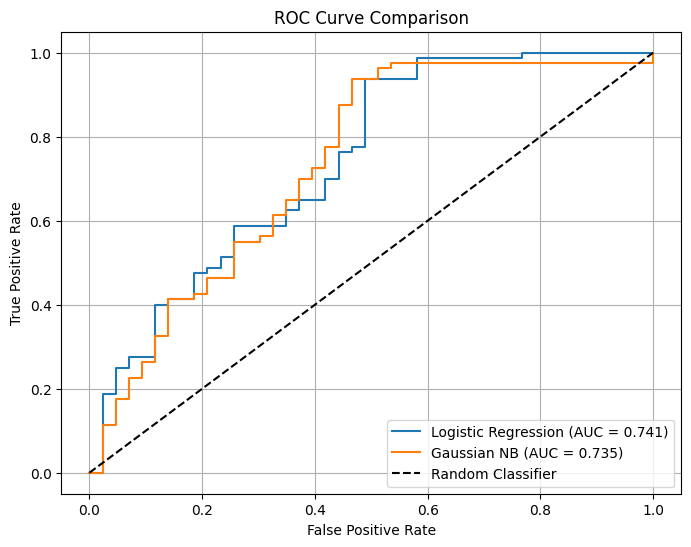

In [30]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {auc_lr:.3f})")

plt.plot(fpr_gnb, tpr_gnb,
         label=f"Gaussian NB (AUC = {auc_gnb:.3f})")

plt.plot([0,1], [0,1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid(True)

plt.show()

Model Evaluation

Two classification algorithms were implemented to predict loan eligibility:

Logistic Regression
Gaussian Naive Bayes

The models were evaluated using:

Accuracy Score
Confusion Matrix
Precision
Recall
F1-score
ROC-AUC Score
Performance Comparison
Model	Accuracy	AUC Score
Logistic Regression	78.86%	0.741
Gaussian Naive Bayes	78.05%	0.735
Confusion Matrix Analysis
Logistic Regression

The confusion matrix shows:

True Positives (Approved loans correctly predicted): 79
True Negatives (Rejected loans correctly predicted): 18
False Positives: 25
False Negatives: 1

The model performs well in identifying approved loan applications, achieving a high recall score for the approved class.

Gaussian Naive Bayes

Gaussian Naive Bayes also achieved similar performance:

True Positives: 78
True Negatives: 18
False Positives: 25
False Negatives: 2

The results indicate that Gaussian Naive Bayes has comparable classification capability but slightly lower performance than Logistic Regression.

ROC-AUC Analysis

The ROC curve was plotted to compare the classification performance of both models.

Logistic Regression achieved an AUC score of 0.741.
Gaussian Naive Bayes achieved an AUC score of 0.735.

A higher AUC indicates better ability of a model to distinguish between loan approval and rejection classes. Logistic Regression slightly outperformed Gaussian Naive Bayes, showing better classification capability.

Final Conclusion

Based on the evaluation results, Logistic Regression performed slightly better than Gaussian Naive Bayes for loan eligibility prediction. It achieved higher accuracy (78.86%) and a higher ROC-AUC score (0.741). Therefore, Logistic Regression was selected as the final model for predicting loan approval status.
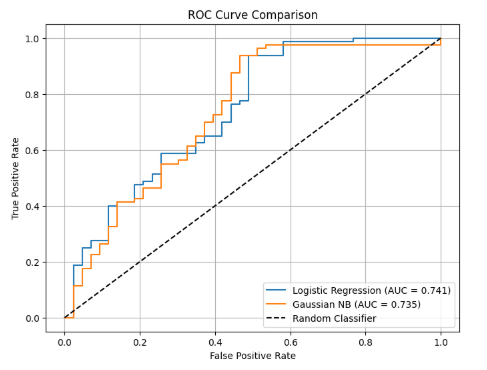